Download CSV from here https://drive.google.com/file/d/1RVSEa69Vo-IPhvDl6d5sm5JLNQXL92iT/view?usp=drive_link

In [ ]:
from google.colab import files
import pandas as pd

# Step 1: Upload your CSV file
uploaded = files.upload()

# Step 2: Get the filename (Colab shows the key of the uploaded dict)
filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

# Step 3: Read the CSV into a pandas DataFrame
df = pd.read_csv(filename)

# Step 4: Display the first few rows
df.head()

Saving Karnataka_Land_Distriibution_csv.csv to Karnataka_Land_Distriibution_csv.csv
Uploaded file: Karnataka_Land_Distriibution_csv.csv


,Taluk name,Total Agricultural Land Holders _Others_Numbers_Male,Total Agricultural Land Holders _Other_Numbers_Female,Total Agricultural Land Holders _Others_Numbers_Institution,Total Agricultural Land Holders _Others_Numbers_Total,Total Agricultural Land Holders _Others_Area_Male,Total Agricultural Land Holders _Others_Area_Female,Total Agricultural Land Holders _Others_Area_Institutions,Total Agricultural Land Holders _Others_Area_Total,Ratio
0,Chikkodi,50273,3741.0,0.0,54014.0,20382.06,935.37,0.0,21317.43,0.394665
1,Athani,65433,7850.0,0.0,73283.0,74331.91,5915.15,0.0,80247.06,1.095030
2,Raibag,40145,3097.0,0.0,43242.0,69593.00,4353.00,0.0,73946.00,1.710050
3,Gokak,31295,2243.0,0.0,33538.0,19515.00,2425.74,0.0,21940.74,0.654205
4,Hukkeri,42228,3308.0,0.0,45536.0,56600.00,4090.00,0.0,60690.00,1.332792


In [ ]:
df = df[~df['Taluk name'].str.contains('total', case=False, na=False)]

# 3. Convert to numeric first
df['Total Agricultural Land Holders _Others_Numbers_Total'] = pd.to_numeric(
    df['Total Agricultural Land Holders _Others_Numbers_Total'],
    errors='coerce'
)

# 4. Fill NaN values with 0 (or drop them)
df['Total Agricultural Land Holders _Others_Numbers_Total'] = df['Total Agricultural Land Holders _Others_Numbers_Total'].fillna(0)

# 5. Now convert to integer (removes .0)
df['Total Agricultural Land Holders _Others_Numbers_Total'] = df['Total Agricultural Land Holders _Others_Numbers_Total'].astype(int)

# Now display
df.head()

,Taluk name,Total Agricultural Land Holders _Others_Numbers_Male,Total Agricultural Land Holders _Other_Numbers_Female,Total Agricultural Land Holders _Others_Numbers_Institution,Total Agricultural Land Holders _Others_Numbers_Total,Total Agricultural Land Holders _Others_Area_Male,Total Agricultural Land Holders _Others_Area_Female,Total Agricultural Land Holders _Others_Area_Institutions,Total Agricultural Land Holders _Others_Area_Total,Ratio
0,Chikkodi,50273,3741.0,0.0,54014,20382.06,935.37,0.0,21317.43,0.394665
1,Athani,65433,7850.0,0.0,73283,74331.91,5915.15,0.0,80247.06,1.095030
2,Raibag,40145,3097.0,0.0,43242,69593.00,4353.00,0.0,73946.00,1.710050
3,Gokak,31295,2243.0,0.0,33538,19515.00,2425.74,0.0,21940.74,0.654205
4,Hukkeri,42228,3308.0,0.0,45536,56600.00,4090.00,0.0,60690.00,1.332792


In [ ]:
# Check for NaN values
print(df['Total Agricultural Land Holders _Others_Numbers_Total'].isna().sum())

# See which rows have NaN
print(df[df['Total Agricultural Land Holders _Others_Numbers_Total'].isna()])

0
Empty DataFrame
Columns: [Taluk name, Total Agricultural Land Holders _Others_Numbers_Male, Total Agricultural Land Holders _Other_Numbers_Female, Total Agricultural Land Holders _Others_Numbers_Institution, Total Agricultural Land Holders _Others_Numbers_Total, Total Agricultural Land Holders _Others_Area_Male, Total Agricultural Land Holders _Others_Area_Female, Total Agricultural Land Holders _Others_Area_Institutions, Total Agricultural Land Holders _Others_Area_Total, Ratio]
Index: []


In [ ]:
# total of people and ratio
total_people = df['Total Agricultural Land Holders _Others_Numbers_Total'].sum()
print("Total Others:", total_people)

total_ratio = df['Ratio'].sum()
print("Total Rtaio:", total_ratio)

Total Others: 7167460
Total Rtaio: 444.922134746


In [ ]:
# Filter rows where Ratio <= 1.5
filtered = df[df['Ratio'] <= 1.5]

# Keep only Taluk name, Others total and Ratio
filtered = filtered[['Taluk name',
                     'Total Agricultural Land Holders _Others_Numbers_Total',
                     'Ratio']]

# See result
filtered.head()

,Taluk name,Total Agricultural Land Holders _Others_Numbers_Total,Ratio
0,Chikkodi,54014,0.394665
1,Athani,73283,1.095030
3,Gokak,33538,0.654205
4,Hukkeri,45536,1.332792
5,Belagavi,48945,1.223455


In [ ]:
# number of land holders with the ratio of less than or equal to 1.5
total_people_ = filtered['Total Agricultural Land Holders _Others_Numbers_Total'].sum()
print("Total Of People:", total_people_)

total_ratio_ = filtered['Ratio'].sum()
print("Total Of Rtaio:", total_ratio_)

Total Of People: 4404862
Total Of Rtaio: 115.88424124000002


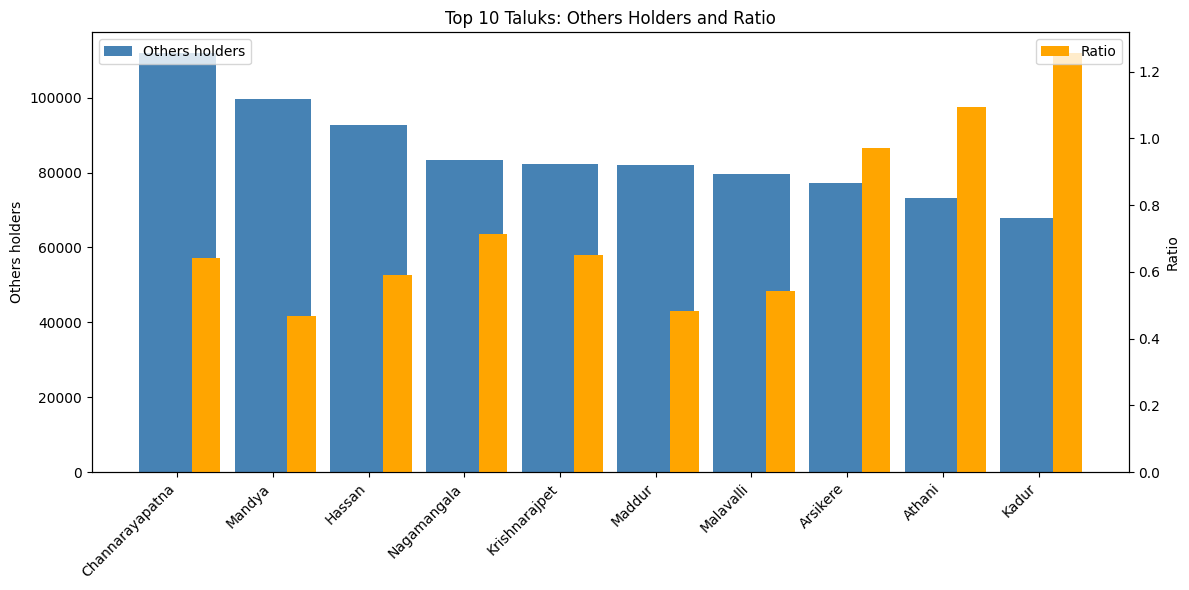

In [ ]:
import matplotlib.pyplot as plt

# Take top 10 taluks by Others holders
top10 = df.sort_values(
    'Total Agricultural Land Holders _Others_Numbers_Total',
    ascending=False
).head(10)

# Plot side‑by‑side bars: Others count (left axis) and Ratio (right axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(top10))

# Bar for Others count
ax1.bar(
    x,
    top10['Total Agricultural Land Holders _Others_Numbers_Total'],
    color='steelblue',
    label='Others holders'
)
ax1.set_ylabel('Others holders')
ax1.set_xticks(x)
ax1.set_xticklabels(top10['Taluk name'], rotation=45, ha='right')

# Second axis for Ratio
ax2 = ax1.twinx()
ax2.bar(
    [i + 0.3 for i in x],
    top10['Ratio'],
    width=0.3,
    color='orange',
    label='Ratio'
)
ax2.set_ylabel('Ratio')

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Top 10 Taluks: Others Holders and Ratio')
plt.tight_layout()
plt.show()


In [ ]:
# Totals
total_people  = 7167460
total_ratio   = 444.922134746

# Subtotals for filtered taluks
people_le_1_5 = 4404862
ratio_le_1_5  = 115.88424124000002

# Percentages
people_pct = people_le_1_5 / total_people * 100
ratio_pct  = ratio_le_1_5 / total_ratio * 100

print("People % with ratio ≤ 1.5:", people_pct)
print("Ratio % with ratio ≤ 1.5:", ratio_pct)

People % with ratio ≤ 1.5: 61.456387618486886
Ratio % with ratio ≤ 1.5: 26.045959998406637


61% of people holding 26% of area